# Assignment 03

In [118]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import geopandas as gpd
import xarray as xr

import datetime
import matplotlib.dates as mdates
import matplotlib.units as munits
converter = mdates.ConciseDateConverter()
munits.registry[np.datetime64] = converter
munits.registry[datetime.date] = converter
munits.registry[datetime.datetime] = converter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1. Global methane levels from 2002

Methane (CH4) is a naturally occurring Greenhouse Gas (GHG), but one whose abundance has been increased substantially above its pre-industrial value by human activities, primarily because of agricultural emissions (e.g., rice production, ruminants) and fossil fuel production and use. A clear annual cycle is largely due to seasonal wetland emissions.

Atmospheric methane abundance is indirectly observed by various satellite instruments. These instruments measure spectrally resolved near-infrared and infrared radiation reflected or emitted by the Earth and its atmosphere. In the measured signal, molecular absorption signatures from methane and constituent gasses can be identified. It is through analysis of those absorption lines in these radiance observations that the averaged methane abundance in the sampled atmospheric column can be determined.

For this problem set, methane levels have been determined by applying several algorithms to different satellite instruments. Download the netCDF4 file (200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc), which contains monthly-averaged methane levels (xch4) in the unit of ppb at each 5° (lon) x 5° (lat) grid over the globe from 2003-01 to 2020-06.

### 1.1

[5 points] Compute methane climatology for each month, and plot your results in 12 panels.

这里首先对原始数据进行了处理，去除了空值，并将单位转换为 ppb。此外，考虑到不同月份的观测数量不同，因此使用观测数进行加权（这里没有使用观测误差进行加权，因为考虑到这可能会使得结果偏低，因为一般低观测误差对应着低浓度信号）。

对月份进行平均后，使用 xr 的 plot 方法绘制了结果。

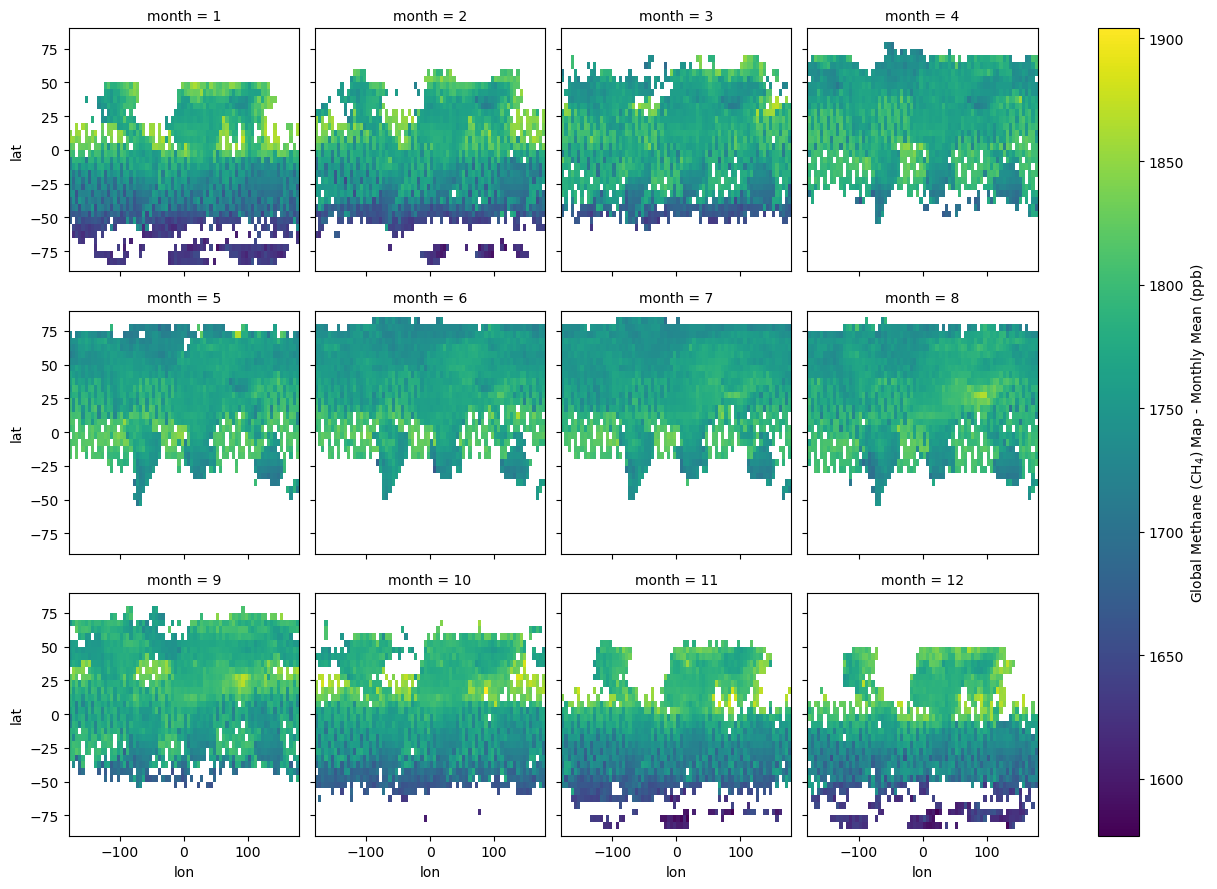

In [185]:
ds = xr.open_dataset("./data/200301_202006-C3S-L3_GHG-PRODUCTS-OBS4MIPS-MERGED-v4.3.nc")
# ds["xch4"][ds["xch4"]==1e20] = np.nan
xch4 = xr.where(ds["xch4"]==1e20, np.nan, ds["xch4"])*1e9
nobs = ds["xch4_nobs"].fillna(0)
# data_draw = xch4.groupby(ds.time.dt.month).mean()
data_draw = ((xch4*nobs).groupby(ds.time.dt.month).sum()/nobs.groupby(ds.time.dt.month).sum())
xr_plot = data_draw.plot(col="month", col_wrap=4, cbar_kwargs={'label':r'Global Methane (CH$_4$) Map - Monthly Mean (ppb)'})
xr_plot.fig.savefig("./images/PS3_1_figure1.png", bbox_inches="tight", dpi=300, transparent=True)

### 1.2

[5 points] Plot globally-averaged methane from 2003-01 to 2020-06 as a time series. Describe your results. Check your plot with [this one](https://svs.gsfc.nasa.gov/5007).

考虑到 NASA 计算的结果使用的是全球海表的甲烷柱浓度数据，这里使用的权重为观测数、纬度余弦值、海面积分数的乘积。

这里使用 xr 的 plot 方法对结果进行了绘制，并将绘图范围与 NASA 的结果保持一致。

可以观察到，全球海洋甲烷柱浓度均值有明显的季节变化，其浓度夏季高、冬季低；从长期来看，甲烷的浓度在逐年增加，从 2003 年的 1725ppb 左右增加至 2020 年的 1825ppb 左右。另外 NASA 使用的为海洋表面数据，相比较柱浓度数据会偏高，不过两者总体趋势一致。

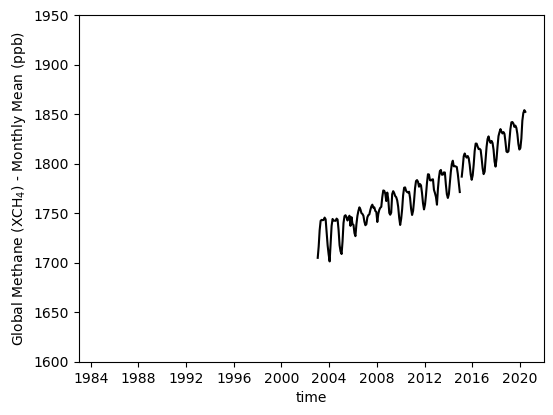

In [186]:
fig = plt.figure(figsize=[6, 4.5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
ax = fig.add_subplot(spec[0])
weight = nobs * np.cos(np.deg2rad(xch4.lat)).values[:, None] * (1 - ds["land_fraction"])
xch4.sel(time=slice("2003-01", "2020-06")).weighted(weight).mean(dim=["lon", "lat"]).plot(ylim=[1600, 1950], ax=ax, color="k", xlim=[np.datetime64("1983-01-01"), np.datetime64("2022-01-02")])
ax.set_ylabel(r'Global Methane (XCH$_4$) - Monthly Mean (ppb)')
fig.savefig("./images/PS3_1_figure2.png", bbox_inches="tight", dpi=300, transparent=True)

### 1.3

[5 points] Plot deseasonalized methane levels at point [15°S, 150°W] from 2003-01 to 2020-06 as a time series. Describe your results.

首先通过减去甲烷各月份的气候态得到距平结果以去除季节变化，并将结果插值到点位 [15°S, 150°W]，并将结果绘制如下。

由于该点位位于太平洋中心，受到观测手段的限制，有效观测数据较少，可以在结果中看到有很多时段没有相关数据。但从整体变化来看，在该位置的甲烷柱浓度也在逐年增加。

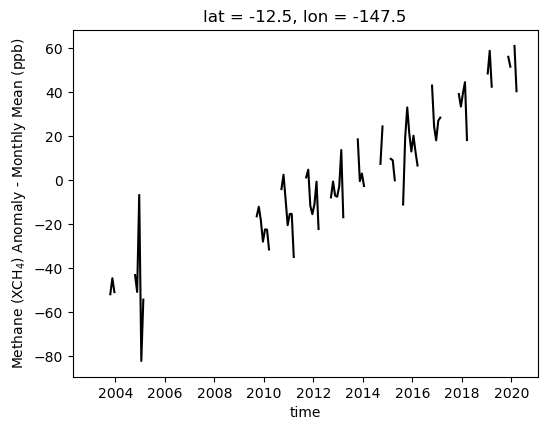

In [187]:
xch4_anmo = xch4.groupby(xch4.time.dt.month) - xch4.groupby(xch4.time.dt.month).mean()
fig = plt.figure(figsize=[6, 4.5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
ax = fig.add_subplot(spec[0])
xch4_anmo.sel(lon=-150, lat=-15, method="bfill").sel(time=slice("2003-01", "2020-06")).plot(ax=ax, color="k")
ax.set_ylabel(r'Methane (XCH$_4$) Anomaly - Monthly Mean (ppb)')
fig.savefig("./images/PS3_1_figure3.png", bbox_inches="tight", dpi=300, transparent=True)

## 2. Niño 3.4 index

The Niño 3.4 anomalies may be thought of as representing the average equatorial sea surface temperatures (SSTs) across the Pacific from about the dateline to the South American coast (5N-5S, 170W-120W). The Niño 3.4 index typically uses a 3-month running mean, and El Niño or La Niña events are defined when the Niño 3.4 SSTs exceed +/- 0.5°C for a period of 5 months or more. Check [Equatorial Pacific Sea Surface Temperatures](https://zhu-group.github.io/ese5023/Assignment_03.html#:~:text=Equatorial%20Pacific%20Sea%20Surface%20Temperatures) for more about the Niño 3.4 index.

In this problem set, you will use the sea surface temperature (SST) data from [NOAA](https://www.noaa.gov/). Download the netCDF4 file (NOAA_NCDC_ERSST_v3b_SST.nc).

### 2.1

[10 points] Compute monthly climatology for SST from Niño 3.4 region, and subtract climatology from SST time series to obtain anomalies.

计算 Niño 3.4 区域的 SST 气候态，并据此计算了 SST 距平。计算时使用了纬度余弦进行加权。并将结果绘制如下。

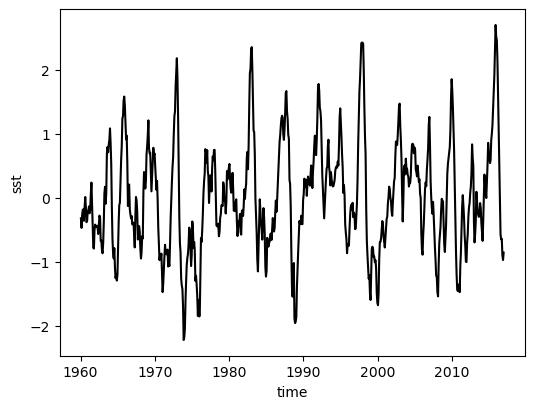

In [188]:
ds = xr.open_dataset("./data/NOAA_NCDC_ERSST_v3b_SST.nc")
ds_nino = ds.sel(lon=slice(-170+360, -120+360), lat=slice(-5, 5))
# nino_sst = ds_nino["sst"].weighted(np.cos(ds_nino.lat)).mean(dim=["lon", "lat"])
nino_sst = ds_nino["sst"].weighted(np.cos(np.deg2rad(ds_nino.lat))).mean(dim=["lon", "lat"])
nino_sst_anom = nino_sst.groupby("time.month") - nino_sst.groupby("time.month").mean()
fig = plt.figure(figsize=[6, 4.5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
ax = fig.add_subplot(spec[0])
nino_sst_anom.plot(ax=ax, color="k")
fig.savefig("./images/PS3_2_figure1.png", bbox_inches="tight", dpi=300, transparent=True)

### 2.2

[10 points] Visualize the computed Niño 3.4. Your plot should look similar to [this one](https://zhu-group.github.io/ese5023/Assignment_03.html#:~:text=look%20similar%20to-,this%20one,-.).

对之前计算的距平进行了滑动平均得到 Niño 3.4 指数，并进行了可视化。为了方便与 NOAA 的案例进行对照，这里使用了相似的 XY 轴范围以及配色。两者结果基本一致。

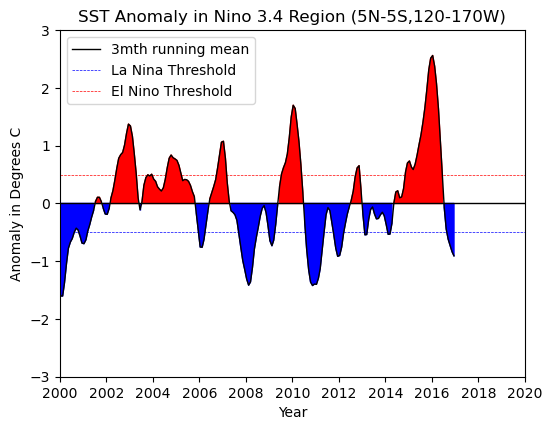

In [189]:
data_draw = nino_sst_anom.rolling(time=3).mean()
x = data_draw.indexes["time"]
y = data_draw.values
y0, y1, y2 = np.zeros_like(y), y.copy(), y.copy()
y1[y1>0], y2[y2<0] = np.nan, np.nan
fig = plt.figure(figsize=[6, 4.5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
ax = fig.add_subplot(spec[0])
ax.plot(x, y, "k-", lw=1, zorder=3)
ax.axhline(y=0, color="k", lw=1, zorder=3, label="3mth running mean")
ax.fill_between(x, y0, y1, color="#0000ff", zorder=2)
ax.fill_between(x, y0, y2, color="#ff0000", zorder=2)
ax.axhline(y=-0.5, ls="--", lw=0.5, color="#0000ff", zorder=1, label="La Nina Threshold")
ax.axhline(y=0.5, ls="--", lw=0.5, color="#ff0000", zorder=1, label="El Nino Threshold")
ax.set(ylim=[-3, 3], xlim=[np.datetime64("2000-01"), np.datetime64("2020-01")], title="SST Anomaly in Nino 3.4 Region (5N-5S,120-170W)", ylabel="Anomaly in Degrees C", xlabel="Year")
ax.legend()
fig.savefig("./images/PS3_2_figure2.png", bbox_inches="tight", dpi=300, transparent=True)

## 3. Explore a netCDF dataset

Browse the NASA’s Goddard Earth Sciences Data and Information Services Center (GES DISC) [website](https://disc.gsfc.nasa.gov/). Search and download a dataset you are interested in. You are also welcome to use data from your group in this problem set. But the dataset should be in netCDF format, and have temporal information.

这里选择数据为 [TROPOMI 的月均全球 0.1° NO2 观测数据](https://disc.gsfc.nasa.gov/datasets/HAQ_TROPOMI_NO2_GLOBAL_M_L3_2.4/summary)。考虑到数据量相对单个仓库较为庞大（>2GB），这里仅保留最终用于绘图的数据（所有时段的平均值 HAQ_TROPOMI_NO2_GLOBAL_QA75_L3_Monthly_Mean_V2.4_201901_to_202508.nc 以及中国区域周边的切片 HAQ_TROPOMI_NO2_CHINA_QA75_L3_Monthly_V2.4.nc）。

### 3.1

[5 points] Plot a time series of a certain variable with monthly seasonal cycle removed.

这里绘制了北京市对流层 NO2 柱浓度的月变化，使用纬度对原始数据进行加权，并通过计算距平去除季节变化。结果绘制如下，可见北京市的对流层 NO2 柱浓度有逐年下降的趋势，这反应了对于地方污染的治理结果。

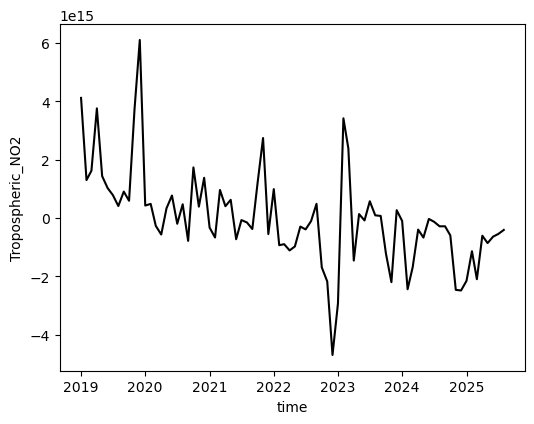

In [190]:
ds = xr.open_dataset("./data/HAQ_TROPOMI_NO2_CHINA_QA75_L3_Monthly_V2.4.nc")
ds_mask = xr.open_dataset("./data/mask_china_province.nc")
# ds_mask["mask"]
da = ds["Tropospheric_NO2"].weighted((ds_mask["mask"]==0)*np.cos(np.deg2rad(ds.lat))).mean(dim=["lon", "lat"])
da_anom = da.groupby("time.month") - da.groupby("time.month").mean()
fig = plt.figure(figsize=[6, 4.5], dpi=100)
spec = fig.add_gridspec(ncols=1, nrows=1)
ax = fig.add_subplot(spec[0])
da_anom.plot(ax=ax, color="k")
fig.savefig("./images/PS3_3_figure1.png", bbox_inches="tight", dpi=300, transparent=True)

### 3.2

[10 points] Make at least 5 different plots using the dataset.

这里依据数据，绘制了 5 张不同的图如下，分别为：

- (a) 折线图，描述了陆地对流层 NO2 柱浓度随纬度变化，可以看到北半球 NO2 显著高于南半球，这与北半球交通更为发达相关
- (b) 网格地图，这里展示了 2019 至 2025 年的平均平流层 NO2 柱浓度，可以看到陆地的 NO2 浓度显著更高，并且通过设置对数坐标突出了一些低浓度的排放，例如航线上的 NO2 排放。受到卫星观测数据的限制，两极区域原始数据并未提供相关结果
- (c) 柱状图，这里展示了 2019 至 2025 年中国的年均平流层 NO2 柱浓度，在计算时使用了纬度余弦进行加权。可以看到中国的地表 NO2 浓度正在逐年下降（其中 2020 年受到疫情封控影响 NO2 排放较低）
- (d) 等高线填色地图，这里展示了中国大陆周边的平流层 NO2 分布情况。可见高浓度区域往往对应人口集中交通较发达的区域。
- (e) 分类填色地图，这里按照不同省份（直辖市）计算了 2020 年 2 月相比较所有时段同月份平流层 NO2 浓度平均值的差异，以体现疫情的影响，可以看到在大多数省市的 NO2 都有了不同程度的下降。

In [191]:
# data for Figure (a, b, d, e)
ds = xr.open_dataset("./data/HAQ_TROPOMI_NO2_GLOBAL_QA75_L3_Monthly_Mean_V2.4_201901_to_202508.nc")
ds_select_china = ds.sel(lon=slice(70, 138), lat=slice(10, 60))
mask_world_land = xr.open_dataset("./data/mask_world_country.nc")["mask"].values
ds_land = ds.copy()
mask_world_land[mask_world_land>=0] = 1
ds_land["Tropospheric_NO2"] *= mask_world_land
no2_lat = ds_land["Tropospheric_NO2"].groupby(ds_land.lat).mean(dim=["lon", "lat"])
no2 = ds["Tropospheric_NO2"].values

# cartopy feature
gdf_world = gpd.read_file("./data/world.zh.json")
gdf_china = gpd.read_file("./data/china_province.geojson").sort_values(by="gb")
geojson_world = gdf_world["geometry"]
geojson_china = gdf_china["geometry"]
gdf_china = gdf_china.loc[gdf_china["name"]!="境界线"]
gdf_china.reset_index(inplace=True)
shp_world = cfeature.ShapelyFeature(geojson_world, ccrs.PlateCarree(), fc="none", ec="k", lw=0.5)
shp_china = cfeature.ShapelyFeature(geojson_china, ccrs.PlateCarree(), fc="none", ec="k", lw=0.5)

# data for Figure (c, e)
ds_china = xr.open_dataset("./data/HAQ_TROPOMI_NO2_CHINA_QA75_L3_Monthly_V2.4.nc")
mask_china = xr.open_dataset("./data/mask_china_province.nc")["mask"].values
mask_china_land = mask_china.copy()
mask_china_land[mask_china_land>=0] = 1
no2_china_t_series = (ds_china["Tropospheric_NO2"]*mask_china_land).weighted(np.cos(np.deg2rad(ds_china.lat))).mean(dim=["lon", "lat"]).groupby("time.year").mean()
ds_china_mean = ds_china.groupby(ds_china.time.dt.month).mean()
for i in range(len(gdf_china)):
    mask_tmp = np.full_like(mask_china, np.nan)
    mask_tmp[mask_china==i] = 1
    gdf_china.loc[i, "no2"] = (ds_china_mean["Tropospheric_NO2"].loc[ds_china_mean.month==2]*mask_tmp).weighted(ds_china_mean.lat).mean().values
    gdf_china.loc[i, "no2_covid19"] = (ds_china["Tropospheric_NO2"].sel(time="2020-02")*mask_tmp).weighted(ds_china_mean.lat).mean().values
gdf_china["no2_covid19_delta"] = gdf_china["no2_covid19"] - gdf_china["no2"]

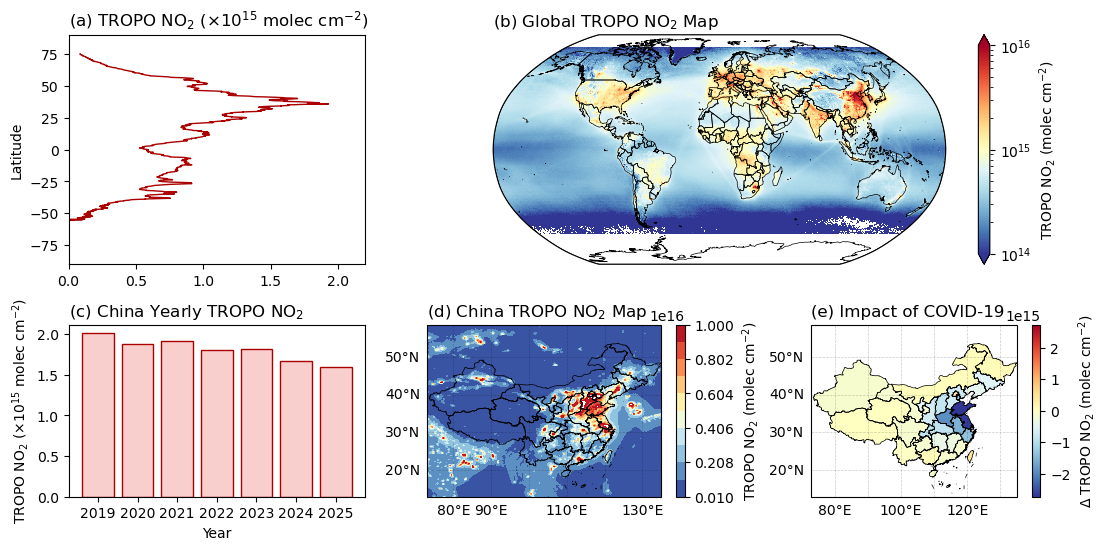

In [192]:
fig = plt.figure(figsize=[13, 6], dpi=100)
spec = fig.add_gridspec(ncols=3, nrows=2, height_ratios=[2, 1.5], hspace=0.3)

# Figure (a)
ax = fig.add_subplot(spec[0, 0])
ax.plot(no2_lat/1e15, no2_lat.lat, color="#AA0000", lw=1)
ax.set(ylim=[-90, 90], xlim=[0, 2.2], ylabel="Latitude")
ax.set_title(r"(a) TROPO NO$_2$ ($\times$10$^{15}$ molec cm$^{-2}$)", loc="left")

# Figure (b)
ax = fig.add_subplot(spec[0, 1:], projection=ccrs.Robinson())
ax.set_extent([-180, 180, -90, 90])
ar = ax.pcolormesh(ds["lon"], ds["lat"], ds["Tropospheric_NO2"], norm=mpl.colors.LogNorm(vmin=1e14, vmax=1e16), cmap="RdYlBu_r", transform=ccrs.PlateCarree())
fig.colorbar(ar, ax=ax, extend="both", label=r"TROPO NO$_2$ (molec cm$^{-2}$)")
ax.add_feature(shp_world)
ax.set_title(r"(b) Global TROPO NO$_2$ Map", loc="left")

# Figure (c)
ax = fig.add_subplot(spec[1, 0])
ax.bar(no2_china_t_series.year, no2_china_t_series.values/1e15, color="#f9cfcd", ec="#AA0000")
ax.set_title(r"(c) China Yearly TROPO NO$_2$", loc="left")
ax.set(xlabel="Year", ylabel=r"TROPO NO$_2$ ($\times$10$^{15}$ molec cm$^{-2}$)", xticks=range(2019, 2026))

# Figure (d)
ax = fig.add_subplot(spec[1, 1], projection=ccrs.PlateCarree())
ax.set_extent([73, 135, 13, 55])
ar = ax.contourf(ds_select_china["lon"], ds_select_china["lat"], ds_select_china["Tropospheric_NO2"], levels=np.linspace(1e14, 1e16, 11, endpoint=True), cmap="RdYlBu_r", transform=ccrs.PlateCarree())
fig.colorbar(ar, ax=ax, extend="both", label=r"TROPO NO$_2$ (molec cm$^{-2}$)")
# gdf_china.plot(ax=ax, column="no2", cmap="RdYlBu_r", norm=mpl.colors.LogNorm(vmin=1e14, vmax=1e16), legend=True)
ax.add_feature(shp_china)
gl = ax.gridlines(color="k", linestyle="--", lw=0.5, draw_labels=True, x_inline=False, y_inline=False, dms=True, alpha=0.2)
gl.top_labels = False
gl.right_labels = False
gl.rotate_labels = False
ax.set_title(r"(d) China TROPO NO$_2$ Map", loc="left")

# Figure (e)
ax = fig.add_subplot(spec[1, 2], projection=ccrs.PlateCarree())
ax.set_extent([73, 135, 13, 55])
gdf_china.plot(ax=ax, column="no2_covid19_delta", cmap="RdYlBu_r", norm=mpl.colors.CenteredNorm(), legend=True, legend_kwds={"label": r"$\Delta$ TROPO NO$_2$ (molec cm$^{-2}$)"})
ax.add_feature(shp_china)
gl = ax.gridlines(color="k", linestyle="--", lw=0.5, draw_labels=True, x_inline=False, y_inline=False, dms=True, alpha=0.2)
gl.top_labels = False
gl.right_labels = False
# gl.left_labels = False
gl.rotate_labels = False
ax.set_title(r"(e) Impact of COVID-19", loc="left")

fig.savefig("./images/PS3_3_figure2.png", bbox_inches="tight", dpi=300, transparent=True)